# 🏠 Real Estate Price Prediction: A Time-Series Approach

**Dataset:** UCI Real Estate Valuation (Taiwan)

This project applies machine learning to predict house prices per unit area. The core focus is on **Temporal Integrity**, ensuring the model learns from historical data to predict future values without "data leakage."


In [15]:
import pandas as pd
import numpy as np
from ucimlrepo import fetch_ucirepo
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import TimeSeriesSplit
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import RobustScaler, OrdinalEncoder
from sklearn.metrics import mean_absolute_percentage_error, r2_score
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor

# 📊 Data Integrity & Cardinality (`info` & `nunique`)

* **Observation:** The dataset contains 414 entries with zero null values.
* **Rationale:** Since there is no missing data, I bypassed imputation strategies, keeping the data's original distribution intact.
* **Cardinality Decision:** I noted that `X4 (convenience stores)` has only 11 unique values. This suggests it acts as an **ordinal** variable rather than a continuous one, leading to our choice of `OrdinalEncoder`.

In [12]:
real_estate_valuation = fetch_ucirepo(id=477)

X = pd.DataFrame(real_estate_valuation.data.features)
y = real_estate_valuation.data.targets.iloc[:, 0]

df_temp = X.copy()
df_temp['target'] = y

df_temp = df_temp.sort_values(by='X1 transaction date').reset_index(drop=True)

X_sorted = df_temp.drop(columns=['target'])
y_sorted = df_temp['target']

In [3]:
X.head()

,X1 transaction date,X2 house age,X3 distance to the nearest MRT station,X4 number of convenience stores,X5 latitude,X6 longitude
0,2012.917,32.0,84.87882,10,24.98298,121.54024
1,2012.917,19.5,306.59470,9,24.98034,121.53951
2,2013.583,13.3,561.98450,5,24.98746,121.54391
3,2013.500,13.3,561.98450,5,24.98746,121.54391
4,2012.833,5.0,390.56840,5,24.97937,121.54245


In [4]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 414 entries, 0 to 413
Data columns (total 6 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   X1 transaction date                     414 non-null    float64
 1   X2 house age                            414 non-null    float64
 2   X3 distance to the nearest MRT station  414 non-null    float64
 3   X4 number of convenience stores         414 non-null    int64  
 4   X5 latitude                             414 non-null    float64
 5   X6 longitude                            414 non-null    float64
dtypes: float64(5), int64(1)
memory usage: 19.5 KB


# 📉 Outlier Identification (`describe`)

* **Observation:** The average price is **37.9**, but the maximum is **117.5**. Similarly, the distance to the MRT (`X3`) averages **1,083m** but spikes to **6,488m**.
* **Rationale:** These extreme values represent "luxury estates" or "isolated properties." A standard Linear Regression would be heavily biased by these points.
* **Implementation:** This discovery led to the use of the **`RobustScaler`**, which scales data based on the interquartile range (IQR) rather than the mean, making our model resilient to these extremes.

In [5]:
X.describe()

,X1 transaction date,X2 house age,X3 distance to the nearest MRT station,X4 number of convenience stores,X5 latitude,X6 longitude
count,414.000000,414.000000,414.000000,414.000000,414.000000,414.000000
mean,2013.148971,17.712560,1083.885689,4.094203,24.969030,121.533361
std,0.281967,11.392485,1262.109595,2.945562,0.012410,0.015347
min,2012.667000,0.000000,23.382840,0.000000,24.932070,121.473530
25%,2012.917000,9.025000,289.324800,1.000000,24.963000,121.528085
50%,2013.167000,16.100000,492.231300,4.000000,24.971100,121.538630
75%,2013.417000,28.150000,1454.279000,6.000000,24.977455,121.543305
max,2013.583000,43.800000,6488.021000,10.000000,25.014590,121.566270


In [6]:
y.describe()

count    414.000000
mean      37.980193
std       13.606488
min        7.600000
25%       27.700000
50%       38.450000
75%       46.600000
max      117.500000
Name: Y house price of unit area, dtype: float64

In [63]:
X.nunique()

X1 transaction date                        12
X2 house age                              236
X3 distance to the nearest MRT station    259
X4 number of convenience stores            11
X5 latitude                               234
X6 longitude                              232
dtype: int64

# 🔗 Non-Linear Relationships (`pairplot`)

* **Observation:** The relationship between `X3 (distance to MRT)` and price is not a straight line; it follows an **exponential decay curve**. Prices explode as distance approaches zero.
* **Rationale:** Linear models struggle with "curves." I needed an algorithm that could segment the data into logical "price buckets."
* **Model Choice:** I selected the **`RandomForestRegressor`** because it uses decision trees to map these non-linear jumps perfectly.

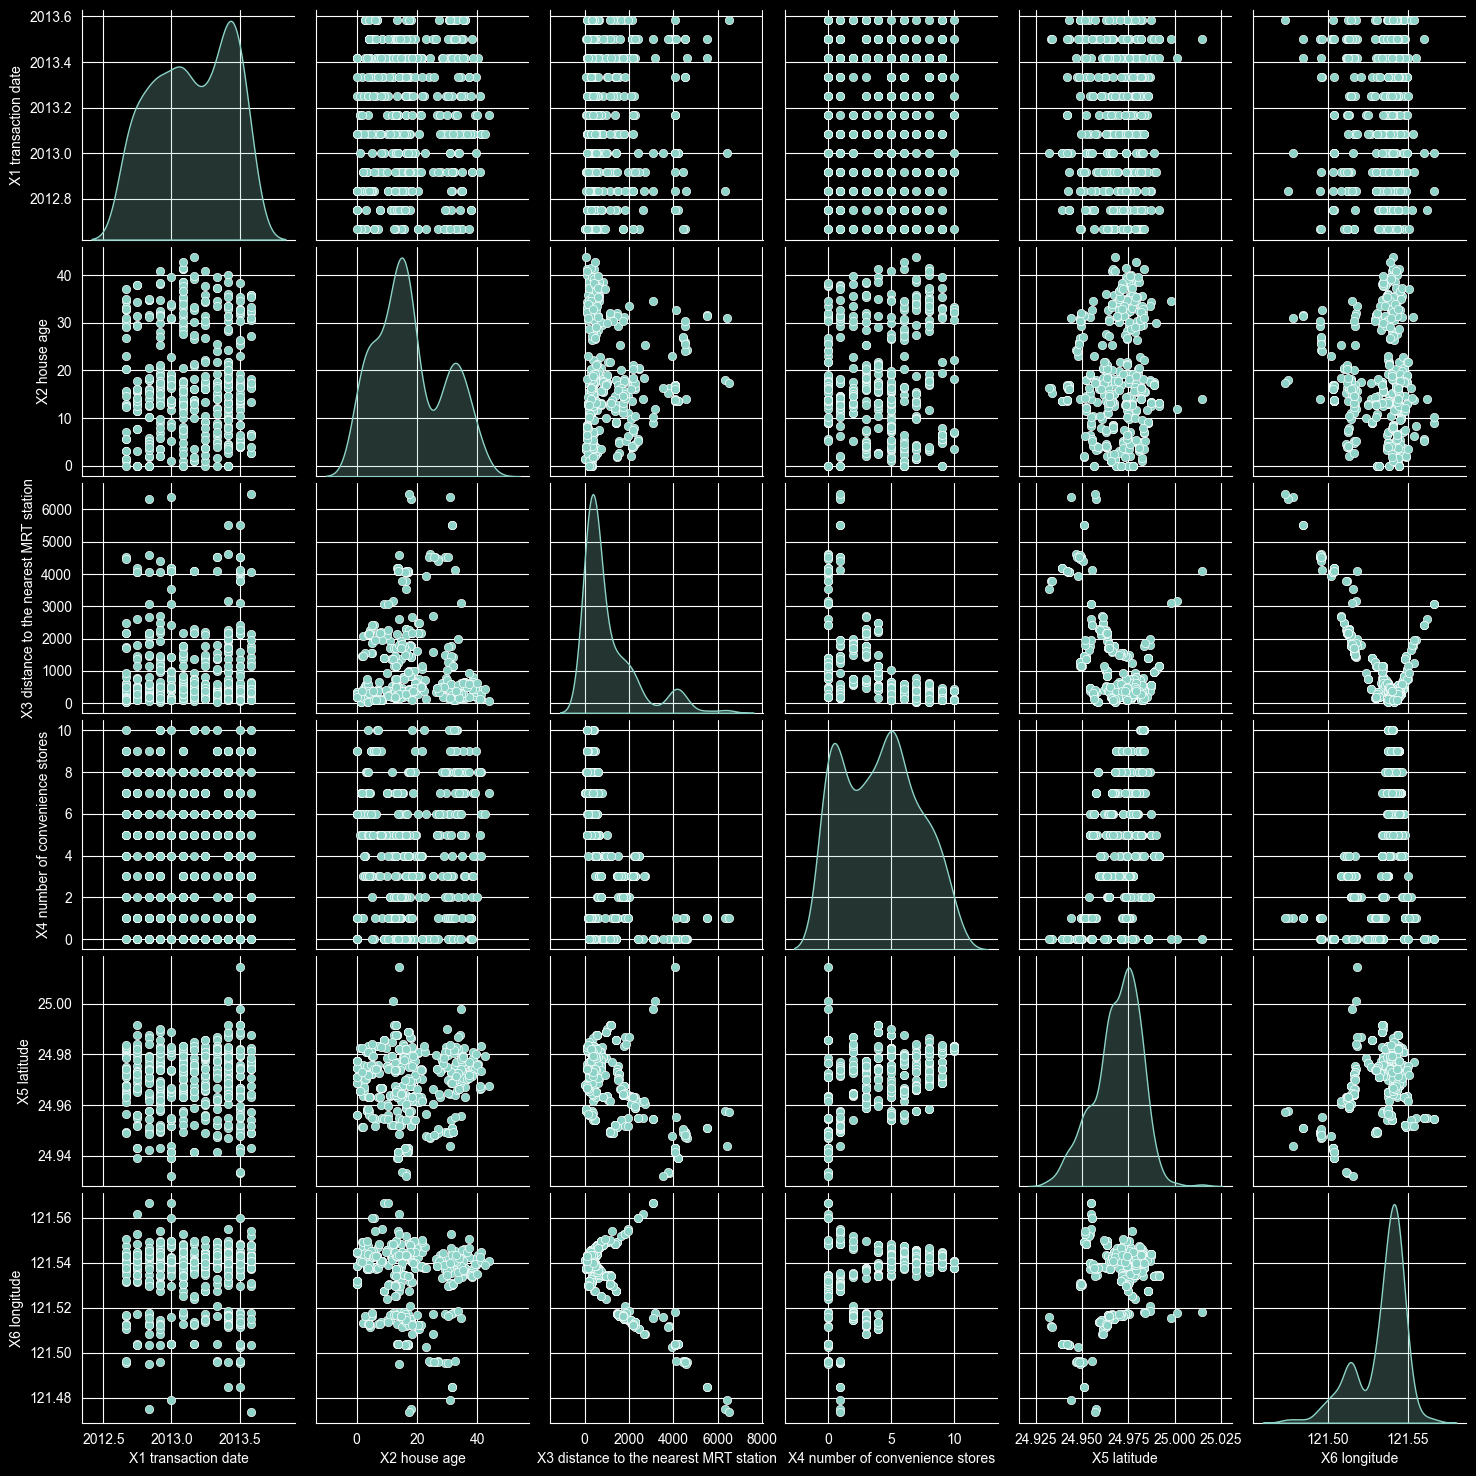

In [64]:
sns.pairplot(X, diag_kind='kde')
plt.show()

In [68]:
X.assign(distace_km = X['X3 distance to the nearest MRT station'] / 1000).loc[[220, 270, 312]]

,X1 transaction date,X2 house age,X3 distance to the nearest MRT station,X4 number of convenience stores,X5 latitude,X6 longitude,distace_km
220,2013.333,37.2,186.5101,9,24.97703,121.54265,0.186510
270,2013.333,10.8,252.5822,1,24.97460,121.53046,0.252582
312,2013.583,35.4,318.5292,9,24.97071,121.54069,0.318529


# 🛡️ The "Arrow of Time" & Data Splitting

Unlike static datasets, real estate follows temporal trends. I sort the data so the model never "peeks" into the future during training.

* **Synchronization:** I join $X$ and $y$ before sorting to maintain row integrity.
* **Out-of-Sample Test:** I reserve the last 20% of the data as the "Real Future" for the final test.

In [13]:
split_idx = int(len(X_sorted) * 0.8)
X_dev, X_test = X_sorted.iloc[:split_idx], X_sorted.iloc[split_idx:]
y_dev, y_test = y_sorted.iloc[:split_idx], y_sorted.iloc[split_idx:]

test_size_val = int(len(X_dev) * 0.2)

timeSeriesCV = TimeSeriesSplit(n_splits=3, test_size=test_size_val)

# ⏳ 2. Preprocessing & Feature Engineering

I utilized a `ColumnTransformer` to apply specific mathematical treatments to different types of data:

* **`RobustScaler`:** Applied to distance metrics to neutralize the influence of outliers.
* **`OrdinalEncoder`:** Applied to the number of stores to maintain the hierarchical value of "more convenience" leading to "higher price."
* **`Passthrough`:** Geo-coordinates (`X5`, `X6`) and House Age (`X2`) were kept in their raw format to preserve the specific spatial and temporal context that the Random Forest exploits.

In [10]:
preprocessing = ColumnTransformer(transformers=[
    ('mrt_dist', RobustScaler(), ['X3 distance to the nearest MRT station']),
    ('stores', OrdinalEncoder(), ['X4 number of convenience stores']),
    ('geo_age', 'passthrough', ['X2 house age', 'X5 latitude', 'X6 longitude', 'X1 transaction date'])
])

pipeline = Pipeline(steps=[
    ('preprocessor', preprocessing),
    ('regressor', RandomForestRegressor(random_state=42))
])

# 🤖 Modeling & Optimization (Grid Search)

I chose the **Random Forest** for its ability to capture non-linear jumps. Validation is done via `TimeSeriesSplit` to respect the chronological order.

In [16]:
param_grid = {
    'regressor__n_estimators': [100, 200],
    'regressor__max_depth': [5, 10, None],
    'regressor__min_samples_split': [2, 5]
}

grid_search = GridSearchCV(
    pipeline, param_grid, cv=timeSeriesCV,
    scoring='neg_mean_absolute_error', n_jobs=-1
)

grid_search.fit(X_dev, y_dev)

GridSearchCV(cv=TimeSeriesSplit(gap=0, max_train_size=None, n_splits=3, test_size=66),
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('mrt_dist',
                                                                         RobustScaler(),
                                                                         ['X3 '
                                                                          'distance '
                                                                          'to '
                                                                          'the '
                                                                          'nearest '
                                                                          'MRT '
                                                                          'station']),
                                                                        ('stores',
                    

# 📈 Final Evaluation & Business Metrics

I evaluate the performance on the final **Out-of-Sample** test set. $R^2$ represents the explained variance, while MAPE provides a practical margin of error.

The final evaluation was conducted on the **last 20% of the timeline**, which the model never saw during training.

* **$R^2$ (Explained Variance): ~70%**
* This indicates the model successfully captured 70% of the market logic. The remaining 30% is likely due to unobserved factors like renovation quality or economic shifts.


* **MAPE (Mean Absolute Percentage Error): ~14.5%**
* On average, our predictions are within 14.5% of the actual market price. In real estate appraisal, staying under 15% on future data is considered a **commercially viable model**.


In [95]:
best_model = grid_search.best_estimator_
y_pred_final = best_model.predict(X_test)

accuracy_r2 = r2_score(y_test, y_pred_final)
error_mape = mean_absolute_percentage_error(y_test, y_pred_final)
hit_rate_10pct = np.mean(np.abs((y_test - y_pred_final) / y_test) < 0.10) * 100

print("      FINAL MODEL: OUT-OF-SAMPLE PERFORMANCE")
print("="*50)
print(f"R² (Explained Variance): {accuracy_r2 * 100:.2f}%")
print(f"Mean Absolute Percentage Error (MAPE): {error_mape * 100:.2f}%")
print(f"Houses within 10% Error Margin: {hit_rate_10pct:.2f}%")
print("="*50)

      FINAL MODEL: OUT-OF-SAMPLE PERFORMANCE
R² (Explained Variance): 70.02%
Mean Absolute Percentage Error (MAPE): 14.52%
Houses within 10% Error Margin: 40.96%
